# Fine Tuning Pre-trained ResNet-50 on MNIST Dataset

In [42]:
import torch, torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import ToTensor, Compose, Normalize, Grayscale
import torch.optim as optim
import torch.nn as nn
import sklearn.metrics
import matplotlib.pyplot as plt

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

mps


### Loading the MNIST dataset

In [35]:
transform_data = Compose([
    Grayscale(num_output_channels=3),                 # 1-ch MNIST -> 3-ch for pretrained conv1
    ToTensor(),
    Normalize((0.485, 0.456, 0.406),                  # ImageNet stats (match pretrained backbone)
            (0.229, 0.224, 0.225)),
])      

# Load the data
batch_size = 256
mnist_train = torchvision.datasets.MNIST(root="./mnist", train=True, download=True, transform=transform_data)
mnist_test = torchvision.datasets.MNIST(root="./mnist", train=False, download=True, transform=transform_data)

train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print("Training data shape:")
print(mnist_train.data.shape)
print("Testing data shape:")
print(mnist_test.data.shape)


Training data shape:
torch.Size([60000, 28, 28])
Testing data shape:
torch.Size([10000, 28, 28])


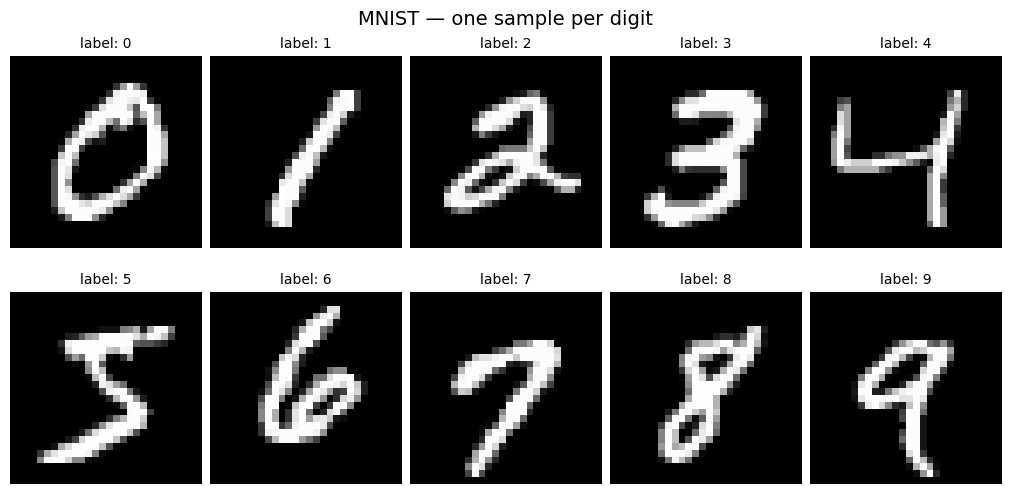

In [44]:
images, labels = mnist_train.data, mnist_train.targets   # raw uint8, 28x28

# one sample per digit, sorted 0..9
idxs = [(labels == d).nonzero(as_tuple=True)[0][0] for d in range(10)]

fig, axes = plt.subplots(2, 5, figsize=(10, 5), constrained_layout=True)
for d, (ax, i) in enumerate(zip(axes.flat, idxs)):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(f"label: {d}", fontsize=10)
    ax.axis("off")
fig.suptitle("MNIST — one sample per digit", fontsize=14)
plt.show()

In [36]:
# fresh, unmodified model every run — avoids the re-execution wrapping trap
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# (1) DO NOT touch conv1 — data is now 3-channel, so pretrained conv1 stays intact
# (2) single linear head: 2048 -> 10
model.fc = nn.Linear(model.fc.in_features, 10)

# (3) freeze all, then unfreeze layer4 + the new head
for p in model.parameters():
    p.requires_grad = False
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"trainable: {trainable:,} / {total:,}")

trainable: 14,985,226 / 23,528,522


In [37]:
# Retrain the custom model on the MNIST dataset
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

# Prepare the model for training
model.train()
model.to(device)

# Retrain the model for a few epochs
num_epochs = 5
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Display training progress
        if (i + 1) % 10 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'.format(epoch+1, \
                                                                      num_epochs, \
                                                                      i+1, \
                                                                      len(train_loader), \
                                                                      loss.item()))

Epoch [1/5], Step [10/235], Loss: 1.5342
Epoch [1/5], Step [20/235], Loss: 0.7019
Epoch [1/5], Step [30/235], Loss: 0.4503
Epoch [1/5], Step [40/235], Loss: 0.3865
Epoch [1/5], Step [50/235], Loss: 0.3504
Epoch [1/5], Step [60/235], Loss: 0.2765
Epoch [1/5], Step [70/235], Loss: 0.2495
Epoch [1/5], Step [80/235], Loss: 0.2418
Epoch [1/5], Step [90/235], Loss: 0.2137
Epoch [1/5], Step [100/235], Loss: 0.2822
Epoch [1/5], Step [110/235], Loss: 0.2509
Epoch [1/5], Step [120/235], Loss: 0.1388
Epoch [1/5], Step [130/235], Loss: 0.1686
Epoch [1/5], Step [140/235], Loss: 0.1212
Epoch [1/5], Step [150/235], Loss: 0.1831
Epoch [1/5], Step [160/235], Loss: 0.1711
Epoch [1/5], Step [170/235], Loss: 0.1401
Epoch [1/5], Step [180/235], Loss: 0.1845
Epoch [1/5], Step [190/235], Loss: 0.1693
Epoch [1/5], Step [200/235], Loss: 0.1321
Epoch [1/5], Step [210/235], Loss: 0.1408
Epoch [1/5], Step [220/235], Loss: 0.2060
Epoch [1/5], Step [230/235], Loss: 0.1032
Epoch [2/5], Step [10/235], Loss: 0.0317
Ep

In [45]:
# --- train side: evaluate over the full 60k training set ---
model.eval()
train_correct = train_total = 0
with torch.no_grad():
    for images, labels in train_loader:
        preds = model(images.to(device)).argmax(1).cpu()
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)
train_acc = train_correct / train_total

In [47]:
# --- test side: reuse arrays from the evaluation cell ---
model.eval()
all_preds, all_labels = [], []
with torch.no_grad(): 
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
        
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_correct = int((all_preds == all_labels).sum())
test_total   = len(all_labels)
test_acc     = test_correct / test_total

In [48]:
gap_pp = (train_acc - test_acc) * 100

if   gap_pp < 3: verdict = "\u2713 Strong generalization \u2014 minimal overfitting"
elif gap_pp < 7: verdict = "~ Moderate generalization \u2014 some overfitting"
else:            verdict = "\u2717 Large gap \u2014 likely overfitting"

bar = "=" * 78
print(bar)
print("CLEAN ACCURACY EVALUATION RESULTS")
print(bar)
print(f"Total test samples:     {test_total:>10,}")
print(f"Correctly classified:   {test_correct:>10,}")
print(f"Clean test accuracy:    {test_acc*100:>9.2f}%")
print()
print(f"Training accuracy:      {train_acc*100:>9.2f}%")
print(f"Generalization gap:     {gap_pp:>+6.2f} percentage points")
print()
print("Interpretation:")
print(f"  {verdict}")
print()
print("Stored arrays for the attack stage:")
print(f"  \u2022 all_clean_preds    (shape: {all_preds.shape})")
print(f"  \u2022 all_clean_labels   (shape: {all_labels.shape})")

CLEAN ACCURACY EVALUATION RESULTS
Total test samples:         10,000
Correctly classified:        9,649
Clean test accuracy:        96.49%

Training accuracy:          99.25%
Generalization gap:      +2.76 percentage points

Interpretation:
  ✓ Strong generalization — minimal overfitting

Stored arrays for the attack stage:
  • all_clean_preds    (shape: (10000,))
  • all_clean_labels   (shape: (10000,))


Accuracy          : 0.9649
Precision (macro) : 0.9645
Recall    (macro) : 0.9646

              precision    recall  f1-score   support

           0     0.9706    0.9755    0.9730       980
           1     0.9877    0.9877    0.9877      1135
           2     0.9743    0.9564    0.9653      1032
           3     0.9575    0.9594    0.9585      1010
           4     0.9530    0.9715    0.9622       982
           5     0.9477    0.9540    0.9508       892
           6     0.9832    0.9749    0.9790       958
           7     0.9612    0.9650    0.9631      1028
           8     0.9453    0.9579    0.9516       974
           9     0.9645    0.9435    0.9539      1009

    accuracy                         0.9649     10000
   macro avg     0.9645    0.9646    0.9645     10000
weighted avg     0.9650    0.9649    0.9649     10000



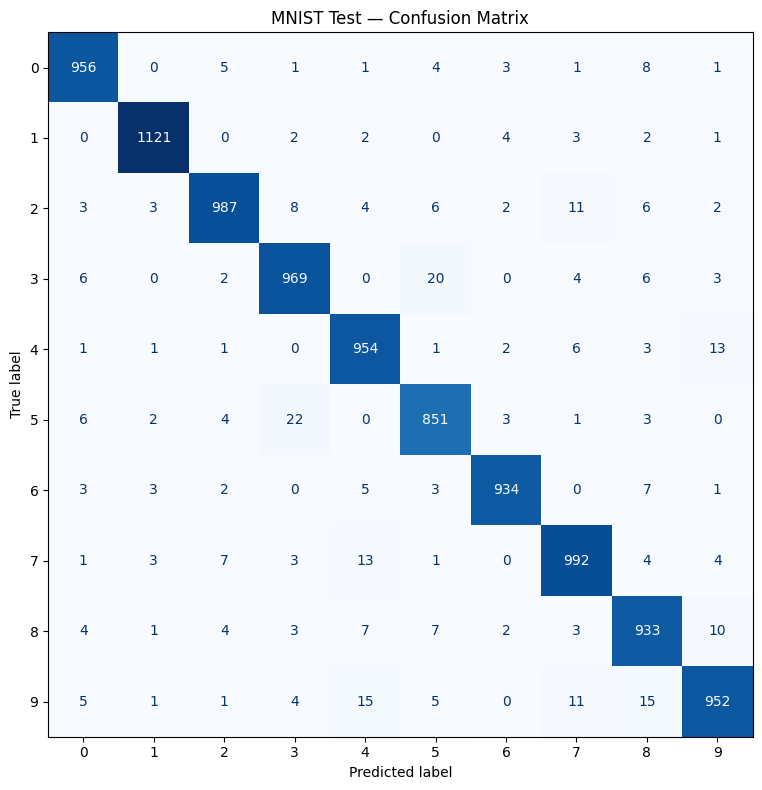

In [39]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
import matplotlib.pyplot as plt

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average="macro")
rec  = recall_score(all_labels, all_preds, average="macro")

print(f"Accuracy          : {acc:.4f}")
print(f"Precision (macro) : {prec:.4f}")
print(f"Recall    (macro) : {rec:.4f}\n")

# per-class precision/recall/F1 in one table
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)   
ax.set_title("MNIST Test — Confusion Matrix")
plt.tight_layout()
plt.show()

In [41]:
torch.save({
    "state_dict": model.state_dict(),
    "num_classes": 10,
    "normalize_mean": (0.485, 0.456, 0.406),
    "normalize_std":  (0.229, 0.224, 0.225),
}, "resnet50_mnist.pt")
print("Saved checkpoint -> resnet50_mnist.pt")

Saved checkpoint -> resnet50_mnist.pt
